# Practical demo: silencing an enhancer and a promoter

A real task: take an enhancer **E** and a promoter **P** at a locus and compare four conditions — **WT**, **dE** (silence E), **dP** (silence P), **dEP** (silence both) — averaged over several cache backgrounds. This walks the whole L0 workflow end to end: define mutations, make backgrounds, marry metadata, and read out the concrete recompute pattern. No model / GPU yet — this is all the spec plumbing a user drives by hand; L1 will consume the specs it produces.

Silencing = `inactivate` (drop in inert sequence), **not** scrambling the element's own bases (which can still read as regulatory).

In [1]:
import sys; sys.path.insert(0, '/workspace/manta-hic-dev')
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from manta_hic.nn.specs import (BIN_BP, random_backgrounds, build_specs, auto_patch_windows,
    tile_pattern, tile_size_bp)
BIN = BIN_BP
print('one MicroZoi tile =', tile_size_bp()//BIN, 'bins =', tile_size_bp(), 'bp')

one MicroZoi tile = 1536 bins = 393216 bp


## 1. Define the locus, the elements, and the four conditions
`inactivate` takes `(start_bp, end_bp)`. The four conditions are just mutation lists; `[]` is wild type.

In [2]:
CHROM, MAP_START = 'chr1', 10_000_000
E = (10_400_000, 10_405_000)   # a 5 kb enhancer
P = (11_000_000, 11_002_000)   # a 2 kb promoter, 600 kb away
dE = ('inactivate', *E)
dP = ('inactivate', *P)
conditions = {'WT': [], 'dE': [dE], 'dP': [dP], 'dEP': [dE, dP]}
for name, muts in conditions.items():
    print(f'{name:4s}: {muts}')

WT  : []
dE  : [('inactivate', 10400000, 10405000)]
dP  : [('inactivate', 11000000, 11002000)]
dEP : [('inactivate', 10400000, 10405000), ('inactivate', 11000000, 11002000)]


## 2. Backgrounds = your replicates
Instead of hand-managed replicate indices, make a set of **backgrounds**: distinct cache runs, each with its own random tile shift, optionally both orientations. Averaging over this axis averages over runs, shifts, and (for random mutations) sequence realizations. The tile pattern is laid out once from the **superset** of all mutations, so every condition shares it.

In [3]:
superset = {dE, dP}
bgs = random_backgrounds(CHROM, MAP_START, runs=4, reverse='both',
                         mutations_superset=superset, rng=np.random.default_rng(0))
print(len(bgs), 'backgrounds (4 runs x fwd/rev)')
for b in bgs[:4]:
    print(f'  run={b.run_idx} rc={b.reverse!s:5s} tile_offset={b.tile_offset_bins:+d} bins')

8 backgrounds (4 runs x fwd/rev)
  run=0 rc=False tile_offset=+180 bins
  run=0 rc=True  tile_offset=+70 bins
  run=1 rc=False tile_offset=+6 bins
  run=1 rc=True  tile_offset=-118 bins


## 3. Marry conditions to backgrounds, with metadata
`build_specs` crosses backgrounds × conditions into the flat spec list you run. Attach per-background metadata (a dict describing each run) and per-condition metadata; it all lands in each spec's `tags` alongside `background` and `mutation_set`. `tags` is what a downstream `group_by` averages over.

In [4]:
bg_meta = [{'run': b.run_idx, 'rc': b.reverse} for b in bgs]
set_meta = {'WT': {'kind': 'ctrl'}, 'dE': {'kind': 'enh'}, 'dP': {'kind': 'prom'}, 'dEP': {'kind': 'both'}}
specs = build_specs(bgs, conditions, background_meta=bg_meta, set_meta=set_meta,
                    rng=np.random.default_rng(1))
print(len(specs), 'specs =', len(bgs), 'backgrounds x', len(conditions), 'conditions')
print('\nexample tags:')
for s in specs[:3] + specs[-1:]:
    print(' ', s.tags, '| n_mut =', len(s.mutations))

# to average over backgrounds for each condition, group by mutation_set:
from collections import Counter
print('\ngroup_by=[mutation_set] ->', dict(Counter(s.tags['mutation_set'] for s in specs)))

32 specs = 8 backgrounds x 4 conditions

example tags:
  {'background': 0, 'mutation_set': 'WT', 'run': 0, 'rc': False, 'kind': 'ctrl'} | n_mut = 0
  {'background': 0, 'mutation_set': 'dE', 'run': 0, 'rc': False, 'kind': 'enh'} | n_mut = 1
  {'background': 0, 'mutation_set': 'dP', 'run': 0, 'rc': False, 'kind': 'prom'} | n_mut = 1
  {'background': 7, 'mutation_set': 'dEP', 'run': 3, 'rc': True, 'kind': 'both'} | n_mut = 2

group_by=[mutation_set] -> {'WT': 8, 'dE': 8, 'dP': 8, 'dEP': 8}


## 4. Two elements far apart -> two patches; close together -> one
The recompute pattern covers each element with `soft_causality + max_shift` (= 512 bins) of margin, then lays MicroZoi tiles. When E and P are far, that's two separate tile runs (two patches); move P next to E and they merge into one. Green = enhancer, orange = promoter, blue = the tiles L1 will recompute.

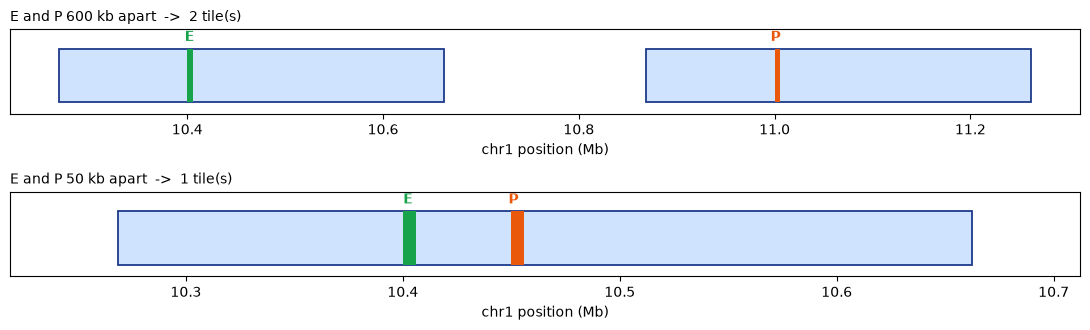

far  -> 2 patches
near -> 1 patch


In [5]:
def show_locus(ax, E, P, title):
    muts = [('inactivate', *E), ('inactivate', *P)]
    tiles = tile_pattern(auto_patch_windows(muts))
    Mb = 1e6
    for lo, hi in tiles:
        ax.add_patch(Rectangle((lo/Mb, 0.15), (hi-lo)/Mb, 0.7, fc='#cfe3ff', ec='#1e3a8a', lw=1.3, zorder=1))
    for (lo, hi), c, lab in [(E, '#16a34a', 'E'), (P, '#ea580c', 'P')]:
        ax.add_patch(Rectangle((lo/Mb, 0.15), max((hi-lo)/Mb, 0.006), 0.7, fc=c, ec='none', zorder=3))
        ax.text((lo+hi)/2/Mb, 0.95, lab, ha='center', color=c, fontweight='bold')
    xs = [t for lohi in tiles for t in lohi]
    ax.set_xlim(min(xs)/Mb - 0.05, max(xs)/Mb + 0.05)
    ax.set_ylim(0, 1.1); ax.set_yticks([]); ax.set_xlabel('chr1 position (Mb)')
    ax.set_title(f'{title}  ->  {len(tiles)} tile(s)', loc='left', fontsize=10)

E_far, P_far = (10_400_000, 10_405_000), (11_000_000, 11_002_000)
E_near, P_near = (10_400_000, 10_405_000), (10_450_000, 10_452_000)
fig, axes = plt.subplots(2, 1, figsize=(11, 3.4))
show_locus(axes[0], E_far, P_far, 'E and P 600 kb apart')
show_locus(axes[1], E_near, P_near, 'E and P 50 kb apart')
plt.tight_layout(); plt.show()
print('far  ->', len(tile_pattern(auto_patch_windows([('inactivate',*E_far),('inactivate',*P_far)]))), 'patches')
print('near ->', len(tile_pattern(auto_patch_windows([('inactivate',*E_near),('inactivate',*P_near)]))), 'patch')

## 5. The mutations are frozen — and differ per background
`inactivate` is random (a fresh inert fill). `build_specs` freezes it **per background**, so averaging over backgrounds also averages over inert realizations. Here are the dE fills across the four runs — all distinct, all 5 kb (the enhancer length), all resolved to a concrete `replace`.

In [6]:
dE_specs = [s for s in specs if s.tags['mutation_set'] == 'dE']
for s in dE_specs:
    op, pos, seq = s.mutations[0]
    print(f"run={s.tags['run']} rc={s.tags['rc']!s:5s}: {op} @ {pos}  len={len(seq)}  {seq[:40]}...")
print('\nall dE fills distinct:', len({s.mutations[0][2] for s in dE_specs}) == len(dE_specs))
# a known (non-random) edit, by contrast, would be identical across backgrounds (freeze is a no-op).

run=0 rc=False: replace @ 10400000  len=5000  GAAAGATCCAATGACAAGCTGCCTGTTGGTATAGCCTTTT...
run=0 rc=True : replace @ 10400000  len=5000  AGTTTTCCAGGCACAATGGTGTTTTCCAAATACTATAAAT...
run=1 rc=False: replace @ 10400000  len=5000  TTTGGGCCACACACTATAGTCAGGCTTAGTAATCAGTTCC...
run=1 rc=True : replace @ 10400000  len=5000  AACTCTGTCAGAACTTTAATAGATGAGAGTAATGTTTTGA...
run=2 rc=False: replace @ 10400000  len=5000  TCATTACAGAGAGATGGTGTCTCACCCACAGGGCAAAGAT...
run=2 rc=True : replace @ 10400000  len=5000  TGGGCAGGCTGTTGTTAGTCCTACCATATTAAAGAACACA...
run=3 rc=False: replace @ 10400000  len=5000  AGCTAGAAAAAGGATGATTTATTAGGGAGAGGGCTTGCCA...
run=3 rc=True : replace @ 10400000  len=5000  ATTAAAAAACCTCCAGTAAAAATGAGGCTATACTAATCTA...

all dE fills distinct: True


## What L1 will do with these specs
Each spec is now fully concrete: a background (cache run + orientation + tile shift + the tile pattern) and frozen mutations. L1 (`fetch_activations_batch`, next) will, per spec: read the cached background, shift the tile pattern by `tile_offset_bins`, recompute those MicroZoi tiles from the mutated sequence, splice them in, and hand back the activation tensor on the GPU — deduplicating identical cache reads within a batch (e.g. the four conditions on one background share one read). Then Manta turns each into a Hi-C map, and grouping by `mutation_set` gives the four averaged conditions to compare.